# N03 — Failure Decomposition

**Question.** Why does the OAI-trained model fail on NHANES III?

This notebook separates two possible causes on the same protected NHANES confirmation knees:

1. **Perception failure:** the image model predicts the radiological concepts incorrectly.
2. **Mapping failure:** OAI and NHANES relate the same radiological concepts to KL grade differently.

Only the two concepts shared by both cohorts are used: osteophytes and sclerosis.

## Reader Guide

**Pipeline role:** Diagnoses why locked transfer fails by separating perception of radiographic concepts from cohort-specific concept-to-grade mapping.

**Inputs:** frozen N02B predictions and N01 cohort records. **Produces:** four-condition predictions, participant-bootstrap effect intervals, concept-level analyses, and a scientific verdict.

**Interpretation boundary:** the comparison uses only concepts genuinely shared across OAI and NHANES III.

## Design

A transparent 16-cell table estimates `P(KL | osteophyte, sclerosis)`.

| Condition | Concepts | Mapping |
|---|---|---|
| A | Model-predicted | OAI |
| B | Human-read | OAI |
| C | Model-predicted | NHANES Discovery |
| D | Human-read | NHANES Discovery |

Main contrasts:

- **Perception repair:** B − A
- **Mapping repair:** D − B
- **Interaction:** D − C − B + A

The protected NHANES confirmation labels never fit either mapping.

In [1]:



from dataclasses import dataclass

from datetime import datetime, timezone

from pathlib import Path

from typing import Any

import hashlib

import json

import shutil

import sys

import uuid

import warnings



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.metrics import (

    accuracy_score,

    balanced_accuracy_score,

    cohen_kappa_score,

    confusion_matrix,

    f1_score,

    mean_absolute_error,

    precision_recall_fscore_support,

)

import torch

from torch import nn

from tqdm.auto import tqdm





@dataclass(frozen=True)

class Config:

    smoothing_grid: tuple[float, ...] = (0.1, 0.5, 1.0, 2.0, 5.0)

    bootstrap_repetitions: int = 2000

    bootstrap_seed: int = 20260805

    leakage_permutations: int = 250

    leakage_seed: int = 20260806

    practical_margin: float = 0.02





CONFIG = Config()



IN_COLAB = (

    "google.colab"

    in sys.modules

)



if IN_COLAB:

    from google.colab import drive



    drive.mount(

        "/content/drive",

        force_remount=False,

    )



MY_DRIVE = Path(

    "/content/drive/MyDrive"

)



if not MY_DRIVE.exists():

    raise RuntimeError(

        "Google Drive is not mounted. "

        "Expected /content/drive/MyDrive."

    )



FINAL_ROOT = Path('/content/drive/MyDrive/MasterThesis/Final Pipeline')



if not FINAL_ROOT.exists():

    raise FileNotFoundError(

        "Final Pipeline root was not found:\n"

        f"{FINAL_ROOT}\n"

        "N02A and N02B use this exact root."

    )



print(

    "Google Drive mounted:",

    MY_DRIVE,

)



print(

    "Final Pipeline root:",

    FINAL_ROOT,

)



DATA_DIR = FINAL_ROOT / 'data' / 'N01'

N02A_CHECKPOINT_DIR = FINAL_ROOT / 'checkpoints' / 'N02A'

N02A_TABLE_DIR = FINAL_ROOT / 'tables' / 'N02A'

N02B_RESULT_DIR = FINAL_ROOT / 'results' / 'N02B'

N02B_PREDICTION_DIR = FINAL_ROOT / 'predictions' / 'N02B'

RESULT_DIR = FINAL_ROOT / 'results' / 'N03'

TABLE_DIR = FINAL_ROOT / 'tables' / 'N03'

FIGURE_DIR = FINAL_ROOT / 'figures' / 'N03'

PREDICTION_DIR = FINAL_ROOT / 'predictions' / 'N03'

MANIFEST_DIR = FINAL_ROOT / 'manifests' / 'N03'



for folder in (RESULT_DIR, TABLE_DIR, FIGURE_DIR, PREDICTION_DIR, MANIFEST_DIR):

    folder.mkdir(parents=True, exist_ok=True)

    for path in folder.iterdir():

        if path.is_file():

            path.unlink()



PROTOCOL = 'N03_FAILURE_DECOMPOSITION'

NOTEBOOK_NAME = 'N03_Failure_Decomposition.ipynb'

RUN_STARTED_TIMESTAMP = datetime.now(timezone.utc).timestamp()

print('Protocol:', PROTOCOL)


Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive
Final Pipeline root: /content/drive/MyDrive/MasterThesis/Final Pipeline
Protocol: N03_FAILURE_DECOMPOSITION


In [2]:



def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:

    digest = hashlib.sha256()

    with path.open('rb') as handle:

        for block in iter(lambda: handle.read(chunk_size), b''):

            digest.update(block)

    return digest.hexdigest()





def atomic_csv(frame: pd.DataFrame, path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + '.tmp')

    frame.to_csv(temporary, index=False)

    temporary.replace(path)





def atomic_json(payload: dict[str, Any], path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + '.tmp')

    temporary.write_text(json.dumps(payload, indent=2), encoding='utf-8')

    temporary.replace(path)





def robust_torch_load(source: Path) -> dict[str, Any]:

    if not source.exists() or source.stat().st_size == 0:

        raise FileNotFoundError(f'Missing checkpoint: {source}')

    staging = Path('/content/n03_checkpoint_staging')

    staging.mkdir(parents=True, exist_ok=True)

    local_path = staging / f'{source.name}.{uuid.uuid4().hex}.pt'

    try:

        shutil.copyfile(source, local_path)

        return torch.load(local_path, map_location='cpu', weights_only=False)

    finally:

        local_path.unlink(missing_ok=True)





def normalize_rows(values: np.ndarray) -> np.ndarray:

    values = np.asarray(values, dtype=np.float64)

    if values.ndim != 2 or not np.isfinite(values).all() or values.min() < -1e-8:

        raise ValueError('Invalid probability matrix.')

    values = np.clip(values, 0.0, None)

    sums = values.sum(axis=1, keepdims=True)

    if (sums <= 0).any():

        raise ValueError('A probability row has zero mass.')

    return values / sums





def one_hot(labels: np.ndarray, classes: int) -> np.ndarray:

    labels = np.asarray(labels, dtype=int)

    if labels.min() < 0 or labels.max() >= classes:

        raise ValueError('Label outside valid range.')

    return np.eye(classes, dtype=np.float64)[labels]





def qwk(truth: np.ndarray, prediction: np.ndarray) -> float:

    with warnings.catch_warnings():

        warnings.simplefilter('ignore')

        value = cohen_kappa_score(

            truth, prediction, labels=list(range(5)), weights='quadratic'

        )

    return float(value)





def metric_values(truth: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:

    probabilities = normalize_rows(probabilities)

    prediction = probabilities.argmax(axis=1)

    return {

        'qwk': qwk(truth, prediction),

        'accuracy': float(accuracy_score(truth, prediction)),

        'balanced_accuracy': float(balanced_accuracy_score(truth, prediction)),

        'macro_f1': float(f1_score(truth, prediction, labels=list(range(5)), average='macro', zero_division=0)),

        'mae': float(mean_absolute_error(truth, prediction)),

        'within_one_accuracy': float((np.abs(prediction - truth) <= 1).mean()),

        'severe_error_rate': float((np.abs(prediction - truth) >= 2).mean()),

    }





def save_figure(figure, name: str) -> None:

    figure.savefig(FIGURE_DIR / f'{name}.png', dpi=300, bbox_inches='tight')

    figure.savefig(FIGURE_DIR / f'{name}.pdf', bbox_inches='tight')

    plt.show()

    plt.close(figure)


## 1. Input gate

N03 consumes only frozen N01, N02A, and N02B artifacts. It performs no image inference and no model training.

In [3]:



OAI_COHORT_PATH = (

    DATA_DIR

    / "oai_cohort.csv"

)



NHANES_COHORT_PATH = (

    DATA_DIR

    / "nhanes_cohort.csv"

)



OAI_PREDICTION_PATH = (

    N02B_PREDICTION_DIR

    / "oai_predictions.csv"

)



NHANES_PREDICTION_PATH = (

    N02B_PREDICTION_DIR

    / "nhanes_predictions.csv"

)



NHANES_SEED_PATH = (

    N02B_PREDICTION_DIR

    / "nhanes_probabilities.npz"

)



N02B_STATUS_PATH = (

    N02B_RESULT_DIR

    / "status.json"

)



TEMPERATURE_PATH = (

    N02A_TABLE_DIR

    / "T04_temperatures.csv"

)





required_inputs = [

    OAI_COHORT_PATH,

    NHANES_COHORT_PATH,

    OAI_PREDICTION_PATH,

    NHANES_PREDICTION_PATH,

    NHANES_SEED_PATH,

    N02B_STATUS_PATH,

    TEMPERATURE_PATH,

]





missing = [

    path

    for path in required_inputs

    if (

        not path.exists()

        or path.stat().st_size == 0

    )

]





if missing:

    print(

        "Mounted MyDrive exists:",

        MY_DRIVE.exists(),

    )



    print(

        "Final Pipeline exists:",

        FINAL_ROOT.exists(),

    )



    print(

        "N02A tables directory exists:",

        N02A_TABLE_DIR.exists(),

    )



    print(

        "N02B predictions directory exists:",

        N02B_PREDICTION_DIR.exists(),

    )



    raise FileNotFoundError(

        "Missing inputs:\n"

        + "\n".join(

            f" - {path}"

            for path in missing

        )

    )










N02B_STATUS = json.loads(

    N02B_STATUS_PATH.read_text(

        encoding="utf-8"

    )

)



if not N02B_STATUS.get(

    "passed",

    False,

):

    raise RuntimeError(

        "N02B did not pass."

    )










OAI = pd.read_csv(

    OAI_COHORT_PATH,

    low_memory=False,

)



NHANES = pd.read_csv(

    NHANES_COHORT_PATH,

    low_memory=False,

)



OAI_PREDICTIONS = pd.read_csv(

    OAI_PREDICTION_PATH,

    low_memory=False,

)



NHANES_PREDICTIONS = pd.read_csv(

    NHANES_PREDICTION_PATH,

    low_memory=False,

)



TEMPERATURES = pd.read_csv(

    TEMPERATURE_PATH,

    low_memory=False,

)












with np.load(

    NHANES_SEED_PATH,

    allow_pickle=True,

) as npz_file:

    NHANES_SEED_DATA = {

        name: npz_file[name]

        for name in npz_file.files

    }





required_npz_arrays = {

    "seeds",

    "knee_key",

    "mapped_kl",

    "direct_kl",

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

}



missing_npz_arrays = (

    required_npz_arrays

    - set(NHANES_SEED_DATA)

)



if missing_npz_arrays:

    raise KeyError(

        "NHANES probability archive is missing arrays: "

        f"{sorted(missing_npz_arrays)}"

    )










required_oai = {

    "knee_key",

    "patient_id",

    "model_split",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

}



required_nhanes = {

    "knee_key",

    "patient_id",

    "analysis_subset",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

}



missing_oai_columns = (

    required_oai

    - set(OAI_PREDICTIONS.columns)

)



missing_nhanes_columns = (

    required_nhanes

    - set(NHANES.columns)

)



if missing_oai_columns:

    raise KeyError(

        "OAI predictions are missing columns: "

        f"{sorted(missing_oai_columns)}"

    )



if missing_nhanes_columns:

    raise KeyError(

        "NHANES cohort is missing columns: "

        f"{sorted(missing_nhanes_columns)}"

    )



if not OAI_PREDICTIONS[

    "knee_key"

].is_unique:

    raise RuntimeError(

        "OAI prediction knee_key is not unique."

    )



if not NHANES_PREDICTIONS[

    "knee_key"

].is_unique:

    raise RuntimeError(

        "NHANES prediction knee_key is not unique."

    )










nhanes_subset_values = (

    NHANES[

        "analysis_subset"

    ]

    .astype(str)

    .str.strip()

    .str.lower()

)



prediction_subset_values = (

    NHANES_PREDICTIONS[

        "analysis_subset"

    ]

    .astype(str)

    .str.strip()

    .str.lower()

)



observed_nhanes_subsets = sorted(

    nhanes_subset_values

    .unique()

    .tolist()

)



observed_prediction_subsets = sorted(

    prediction_subset_values

    .unique()

    .tolist()

)



print(

    "NHANES cohort subsets:",

    observed_nhanes_subsets,

)



print(

    "NHANES prediction subsets:",

    observed_prediction_subsets,

)





expected_cohort_subsets = {

    "discovery",

    "confirmation",

}



if not expected_cohort_subsets.issubset(

    set(observed_nhanes_subsets)

):

    raise RuntimeError(

        "The frozen NHANES cohort must contain "

        "Discovery and Confirmation subsets. "

        f"Observed: {observed_nhanes_subsets}"

    )



if "confirmation" not in set(

    observed_prediction_subsets

):

    raise RuntimeError(

        "N02B predictions must contain the "

        "Confirmation subset. "

        f"Observed: {observed_prediction_subsets}"

    )





NHANES_DISCOVERY = (

    NHANES.loc[

        nhanes_subset_values.eq(

            "discovery"

        )

    ]

    .copy()

    .reset_index(drop=True)

)



NHANES_CONFIRMATION = (

    NHANES_PREDICTIONS.loc[

        prediction_subset_values.eq(

            "confirmation"

        )

    ]

    .copy()

    .reset_index(drop=True)

)




NHANES_ADAPTATION = (

    NHANES_DISCOVERY

)





if len(NHANES_DISCOVERY) == 0:

    raise RuntimeError(

        "NHANES Discovery subset is empty."

    )



if len(NHANES_CONFIRMATION) == 0:

    raise RuntimeError(

        "NHANES Confirmation subset is empty."

    )










discovery_patients = set(

    NHANES_DISCOVERY[

        "patient_id"

    ].astype(str)

)



confirmation_patients = set(

    NHANES_CONFIRMATION[

        "patient_id"

    ].astype(str)

)



overlapping_patients = (

    discovery_patients

    & confirmation_patients

)



if overlapping_patients:

    raise RuntimeError(

        "NHANES Discovery and Confirmation "

        f"patients overlap: {len(overlapping_patients)}"

    )





print(

    "NHANES Discovery knees:",

    len(NHANES_DISCOVERY),

)



print(

    "NHANES Confirmation knees:",

    len(NHANES_CONFIRMATION),

)



print(

    "NHANES split gate: PASS"

)










csv_keys = pd.Index(

    NHANES_CONFIRMATION[

        "knee_key"

    ].astype(str)

)



npz_keys = pd.Index(

    np.asarray(

        NHANES_SEED_DATA[

            "knee_key"

        ]

    ).astype(str)

)



if not csv_keys.is_unique:

    raise RuntimeError(

        "NHANES confirmation CSV knee keys are not unique."

    )



if not npz_keys.is_unique:

    raise RuntimeError(

        "NHANES NPZ knee keys are not unique."

    )



missing_from_npz = (

    csv_keys.difference(

        npz_keys

    )

)



extra_in_npz = (

    npz_keys.difference(

        csv_keys

    )

)



if (

    len(missing_from_npz) > 0

    or len(extra_in_npz) > 0

):

    raise RuntimeError(

        "NHANES CSV and NPZ contain different knees.\n"

        f"Missing from NPZ: {len(missing_from_npz)}\n"

        f"Extra in NPZ: {len(extra_in_npz)}"

    )










input_audit = pd.DataFrame([

    {

        "path": str(path),

        "size_bytes": int(

            path.stat().st_size

        ),

        "sha256": sha256_file(

            path

        ),

    }

    for path in required_inputs

])



atomic_csv(

    input_audit,

    MANIFEST_DIR

    / "input_manifest.csv",

)





print(

    "OAI prediction knees:",

    len(OAI_PREDICTIONS),

)



print(

    "NHANES Discovery knees:",

    len(NHANES_DISCOVERY),

)



print(

    "NHANES Confirmation knees:",

    len(NHANES_CONFIRMATION),

)



print(

    "NHANES NPZ knees:",

    len(npz_keys),

)



print(

    "Input gate: PASS"

)

NHANES cohort subsets: ['confirmation', 'discovery']
NHANES prediction subsets: ['confirmation']
NHANES Discovery knees: 2389
NHANES Confirmation knees: 2392
NHANES split gate: PASS
OAI prediction knees: 5252
NHANES Discovery knees: 2389
NHANES Confirmation knees: 2392
NHANES NPZ knees: 2392
Input gate: PASS


## 2. Shared-concept mapping

The mapper is a smoothed conditional table over the 16 possible osteophyte–sclerosis pairs. Soft concept probabilities are mixed over all 16 pairs.

In [4]:



CONCEPT_COLUMNS = ('osteophyte_max', 'sclerosis_max')





def fit_mapping_table(frame: pd.DataFrame, alpha: float) -> np.ndarray:

    counts = np.full((4, 4, 5), float(alpha), dtype=np.float64)

    for row in frame[['osteophyte_max','sclerosis_max','kl_grade']].itertuples(index=False):

        counts[int(row.osteophyte_max), int(row.sclerosis_max), int(row.kl_grade)] += 1.0

    return counts / counts.sum(axis=2, keepdims=True)





def map_concepts_to_kl(o_probs: np.ndarray, s_probs: np.ndarray, table: np.ndarray) -> np.ndarray:

    o_probs = normalize_rows(o_probs)

    s_probs = normalize_rows(s_probs)

    if table.shape != (4, 4, 5):

        raise ValueError('Mapping table must have shape (4,4,5).')

    joint = o_probs[:, :, None] * s_probs[:, None, :]

    return normalize_rows(np.einsum('nos,osk->nk', joint, table))





OAI_TRAIN = OAI_PREDICTIONS.loc[

    OAI_PREDICTIONS['model_split'].astype(str).str.lower().eq('train')

].copy().reset_index(drop=True)

OAI_VALIDATION = OAI_PREDICTIONS.loc[

    OAI_PREDICTIONS['model_split'].astype(str).str.lower().eq('validation')

].copy().reset_index(drop=True)

if len(OAI_TRAIN) == 0 or len(OAI_VALIDATION) == 0:

    raise RuntimeError('OAI train or validation subset is empty.')



val_o = one_hot(OAI_VALIDATION['osteophyte_max'].to_numpy(dtype=int), 4)

val_s = one_hot(OAI_VALIDATION['sclerosis_max'].to_numpy(dtype=int), 4)

val_y = OAI_VALIDATION['kl_grade'].to_numpy(dtype=int)

alpha_rows = []

for alpha in CONFIG.smoothing_grid:

    table = fit_mapping_table(OAI_TRAIN, alpha)

    values = metric_values(val_y, map_concepts_to_kl(val_o, val_s, table))

    alpha_rows.append({'alpha': float(alpha), **values})



alpha_selection = pd.DataFrame(alpha_rows).sort_values(

    ['qwk','accuracy','mae','alpha'], ascending=[False,False,True,True]

).reset_index(drop=True)

SELECTED_ALPHA = float(alpha_selection.iloc[0]['alpha'])

OAI_MAPPING_FRAME = pd.concat([OAI_TRAIN, OAI_VALIDATION], ignore_index=True)

SOURCE_MAPPING = fit_mapping_table(OAI_MAPPING_FRAME, SELECTED_ALPHA)

TARGET_MAPPING = fit_mapping_table(NHANES_ADAPTATION, SELECTED_ALPHA)

atomic_csv(alpha_selection, TABLE_DIR / 'T01_smoothing_selection.csv')



mapping_rows = []

for name, table in [('OAI', SOURCE_MAPPING), ('NHANES Discovery', TARGET_MAPPING)]:

    for o in range(4):

        for s in range(4):

            row = {'mapping': name, 'osteophyte_grade': o, 'sclerosis_grade': s}

            for k in range(5):

                row[f'kl_probability_{k}'] = float(table[o,s,k])

            mapping_rows.append(row)

atomic_csv(pd.DataFrame(mapping_rows), TABLE_DIR / 'T02_mapping_tables.csv')

print('Selected alpha:', SELECTED_ALPHA)

print('Mapping gate: PASS')


Selected alpha: 0.1
Mapping gate: PASS


## 3. Four-condition decomposition

Only the concept source changes between A and B. Only the concept-to-KL mapping changes between A and C.

In [5]:



def predicted_concept_probabilities(frame: pd.DataFrame, concept: str) -> np.ndarray:

    columns = [f'{concept}_prob_{grade}' for grade in range(4)]

    missing = [column for column in columns if column not in frame.columns]

    if missing:

        raise KeyError(f'Missing {concept} probabilities: {missing}')

    return normalize_rows(frame[columns].to_numpy(dtype=np.float64))



truth_kl = NHANES_CONFIRMATION['kl_grade'].to_numpy(dtype=int)

pred_o = predicted_concept_probabilities(NHANES_CONFIRMATION, 'osteophyte_max')

pred_s = predicted_concept_probabilities(NHANES_CONFIRMATION, 'sclerosis_max')

human_o = one_hot(NHANES_CONFIRMATION['osteophyte_max'].to_numpy(dtype=int), 4)

human_s = one_hot(NHANES_CONFIRMATION['sclerosis_max'].to_numpy(dtype=int), 4)



CONDITION_PROBABILITIES = {

    'A_predicted_OAI_mapping': map_concepts_to_kl(pred_o, pred_s, SOURCE_MAPPING),

    'B_human_OAI_mapping': map_concepts_to_kl(human_o, human_s, SOURCE_MAPPING),

    'C_predicted_NHANES_mapping': map_concepts_to_kl(pred_o, pred_s, TARGET_MAPPING),

    'D_human_NHANES_mapping': map_concepts_to_kl(human_o, human_s, TARGET_MAPPING),

}

condition_metrics = pd.DataFrame([

    {'condition': name, **metric_values(truth_kl, probabilities)}

    for name, probabilities in CONDITION_PROBABILITIES.items()

])

atomic_csv(condition_metrics, TABLE_DIR / 'T03_condition_metrics.csv')



predictions = NHANES_CONFIRMATION[['knee_key','patient_id','kl_grade','osteophyte_max','sclerosis_max']].copy()

for name, probabilities in CONDITION_PROBABILITIES.items():

    for grade in range(5):

        predictions[f'{name}_prob_{grade}'] = probabilities[:,grade]

    predictions[f'{name}_prediction'] = probabilities.argmax(axis=1)

atomic_csv(predictions, PREDICTION_DIR / 'decomposition_predictions.csv')

display(condition_metrics.round(4))


,condition,qwk,accuracy,balanced_accuracy,macro_f1,mae,within_one_accuracy,severe_error_rate
0,A_predicted_OAI_mapping,0.3751,0.3809,0.4282,0.3027,1.0652,0.5811,0.4189
1,B_human_OAI_mapping,0.9015,0.8056,0.4503,0.4444,0.2044,0.9900,0.0100
2,C_predicted_NHANES_mapping,0.3957,0.3131,0.3472,0.2027,1.2847,0.5489,0.4511
3,D_human_NHANES_mapping,0.9520,0.8783,0.7783,0.7588,0.1217,1.0000,0.0000


## 4. Participant bootstrap

Participants, not individual knees, are resampled. Every contrast is recalculated within each draw.

In [6]:



METRICS = ('qwk','accuracy','macro_f1','mae')

CONDITION_ORDER = (

    'A_predicted_OAI_mapping','B_human_OAI_mapping',

    'C_predicted_NHANES_mapping','D_human_NHANES_mapping',

)





def patient_groups(frame: pd.DataFrame) -> list[np.ndarray]:

    values = frame['patient_id'].astype(str).to_numpy()

    return [np.flatnonzero(values == patient) for patient in np.unique(values)]





def sample_indices(groups: list[np.ndarray], rng: np.random.Generator) -> np.ndarray:

    chosen = rng.integers(0, len(groups), size=len(groups))

    return np.concatenate([groups[index] for index in chosen])





def effects(values: dict[str, dict[str,float]], metric: str) -> dict[str,float]:

    a,b,c,d = [values[name][metric] for name in CONDITION_ORDER]

    return {

        'perception_repair_source_mapping': b-a,

        'mapping_repair_predicted_concepts': c-a,

        'mapping_repair_human_concepts': d-b,

        'perception_repair_target_mapping': d-c,

        'interaction': d-c-b+a,

    }



rng = np.random.default_rng(CONFIG.bootstrap_seed)

groups = patient_groups(NHANES_CONFIRMATION)

bootstrap_rows = []

for repetition in tqdm(range(CONFIG.bootstrap_repetitions), desc='Decomposition bootstrap'):

    indices = sample_indices(groups, rng)

    sampled_truth = truth_kl[indices]

    sampled = {

        name: metric_values(sampled_truth, CONDITION_PROBABILITIES[name][indices])

        for name in CONDITION_ORDER

    }

    row = {'repetition': repetition}

    for name in CONDITION_ORDER:

        for metric in METRICS:

            row[f'{name}__{metric}'] = sampled[name][metric]

    for metric in METRICS:

        for effect, value in effects(sampled, metric).items():

            row[f'{effect}__{metric}'] = value

    bootstrap_rows.append(row)

bootstrap_draws = pd.DataFrame(bootstrap_rows)



point_values = {

    row.condition: {metric: float(getattr(row, metric)) for metric in METRICS}

    for row in condition_metrics.itertuples(index=False)

}

effect_rows = []

for metric in METRICS:

    for effect, estimate in effects(point_values, metric).items():

        values = bootstrap_draws[f'{effect}__{metric}'].to_numpy(dtype=float)

        valid = values[np.isfinite(values)]

        if len(valid) == 0:

            raise RuntimeError(f'No valid bootstrap values for {effect}, {metric}.')

        effect_rows.append({

            'effect': effect, 'metric': metric, 'estimate': float(estimate),

            'ci_lower': float(np.quantile(valid,0.025)),

            'ci_upper': float(np.quantile(valid,0.975)),

            'valid_draws': int(len(valid)),

        })

effect_intervals = pd.DataFrame(effect_rows)

atomic_csv(bootstrap_draws, TABLE_DIR / 'T04_bootstrap_draws.csv')

atomic_csv(effect_intervals, TABLE_DIR / 'T05_effect_intervals.csv')

display(effect_intervals.round(4))


Decomposition bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,effect,metric,estimate,ci_lower,ci_upper,valid_draws
0,perception_repair_source_mapping,qwk,0.5264,0.4918,0.5591,2000
1,mapping_repair_predicted_concepts,qwk,0.0206,0.0038,0.0376,2000
2,mapping_repair_human_concepts,qwk,0.0505,0.0423,0.0593,2000
3,perception_repair_target_mapping,qwk,0.5563,0.5292,0.5832,2000
4,interaction,qwk,0.0298,0.0099,0.0488,2000
5,perception_repair_source_mapping,accuracy,0.4247,0.3979,0.4518,2000
6,mapping_repair_predicted_concepts,accuracy,-0.0677,-0.0895,-0.0467,2000
7,mapping_repair_human_concepts,accuracy,0.0727,0.0607,0.0851,2000
8,perception_repair_target_mapping,accuracy,0.5652,0.5428,0.5886,2000
9,interaction,accuracy,0.1405,0.1148,0.1673,2000


## 5. Grade-specific concept failure

This identifies which human concept grades the image model fails to recover.

In [7]:



concept_rows = []

concept_confusions = {}

for concept in CONCEPT_COLUMNS:

    truth = NHANES_CONFIRMATION[concept].to_numpy(dtype=int)

    probabilities = predicted_concept_probabilities(NHANES_CONFIRMATION, concept)

    prediction = probabilities.argmax(axis=1)

    concept_confusions[concept] = confusion_matrix(truth, prediction, labels=list(range(4)))

    precision, recall, f1, support = precision_recall_fscore_support(

        truth, prediction, labels=list(range(4)), zero_division=0

    )

    for grade in range(4):

        concept_rows.append({

            'concept': concept, 'grade': grade, 'support': int(support[grade]),

            'predicted': int(np.sum(prediction == grade)),

            'precision': float(precision[grade]), 'recall': float(recall[grade]),

            'f1': float(f1[grade]),

        })

concept_grade_metrics = pd.DataFrame(concept_rows)

atomic_csv(concept_grade_metrics, TABLE_DIR / 'T06_concept_grade_metrics.csv')

display(concept_grade_metrics.round(4))


,concept,grade,support,predicted,precision,recall,f1
0,osteophyte_max,0,1559,843,0.9229,0.4990,0.6478
1,osteophyte_max,1,641,626,0.2364,0.2309,0.2336
2,osteophyte_max,2,140,321,0.0218,0.0500,0.0304
3,osteophyte_max,3,52,602,0.0864,1.0000,0.1590
4,sclerosis_max,0,1837,1742,0.8978,0.8514,0.8740
5,sclerosis_max,1,482,191,0.3613,0.1432,0.2051
6,sclerosis_max,2,68,185,0.1189,0.3235,0.1739
7,sclerosis_max,3,5,274,0.0146,0.8000,0.0287


## 6. Soft-concept information audit

The original CBM mapping network receives soft concept probabilities.

This section compares:

- **Soft concepts:** the original continuous concept probabilities.
- **Hard concepts:** one-hot argmax concept grades.
- **Permuted soft concepts:** soft vectors shuffled within the same predicted grade.

The goal is to test whether information beyond the discrete concept grades helps or harms external grading.

A higher soft-concept QWK means that the continuous probability structure is useful.

A lower soft-concept QWK means that the continuous probability structure is harmful under domain shift.

In [8]:



class MappingNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(12,64), nn.LayerNorm(64), nn.GELU(),

            nn.Dropout(0.20), nn.Linear(64,5),

        )

    def forward(self, values: torch.Tensor) -> torch.Tensor:

        return self.network(values)





def inverse_temperature(calibrated: np.ndarray, temperature: float) -> np.ndarray:

    calibrated = normalize_rows(calibrated)

    logits = np.log(np.clip(calibrated,1e-12,1.0)) * float(temperature)

    logits -= logits.max(axis=1, keepdims=True)

    return normalize_rows(np.exp(logits))





def apply_temperature(probabilities: np.ndarray, temperature: float) -> np.ndarray:

    probabilities = normalize_rows(probabilities)

    logits = np.log(np.clip(probabilities,1e-12,1.0)) / float(temperature)

    logits -= logits.max(axis=1, keepdims=True)

    return normalize_rows(np.exp(logits))





def mapped_probabilities(network: MappingNetwork, concepts: np.ndarray, temperature: float) -> np.ndarray:

    tensor = torch.from_numpy(concepts.astype(np.float32))

    with torch.inference_mode():

        probabilities = torch.softmax(network(tensor), dim=1).cpu().numpy()

    return apply_temperature(probabilities, temperature)



seed_values = NHANES_SEED_DATA['seeds'].astype(int).tolist()

npz_keys = pd.Index(NHANES_SEED_DATA['knee_key'].astype(str))

csv_keys = pd.Index(NHANES_CONFIRMATION['knee_key'].astype(str))

reorder = npz_keys.get_indexer(csv_keys)

if (reorder < 0).any():

    raise RuntimeError('Could not align NPZ predictions to CSV.')



seed_arrays = {

    name: NHANES_SEED_DATA[name][:,reorder,:]

    for name in ('osteophyte_max','sclerosis_max','jsn_max','mapped_kl')

}

networks, raw_concepts, mapped_temperatures = [], [], []

for seed_index, seed in enumerate(seed_values):

    checkpoint = robust_torch_load(N02A_CHECKPOINT_DIR / f'convnext_tiny_seed{seed}.pt')

    mapping_state = {

        key.replace('concept_mapping.','network.',1): value

        for key, value in checkpoint['model_state_dict'].items()

        if key.startswith('concept_mapping.')

    }

    network = MappingNetwork()

    network.load_state_dict(mapping_state, strict=True)

    network.eval()

    rows = TEMPERATURES.loc[TEMPERATURES['seed'].astype(int).eq(seed)]

    temperatures = {str(row.head): float(row.temperature) for row in rows.itertuples(index=False)}

    parts = [

        inverse_temperature(seed_arrays[name][seed_index], temperatures[name])

        for name in ('osteophyte_max','sclerosis_max','jsn_max')

    ]

    networks.append(network)

    raw_concepts.append(np.concatenate(parts, axis=1))

    mapped_temperatures.append(temperatures['mapped_kl'])

    del checkpoint



soft_outputs = [

    mapped_probabilities(networks[i], raw_concepts[i], mapped_temperatures[i])

    for i in range(len(seed_values))

]

soft_ensemble = normalize_rows(np.mean(np.stack(soft_outputs,axis=0),axis=0))

stored_ensemble = normalize_rows(np.mean(seed_arrays['mapped_kl'],axis=0))

parity_max_difference = float(np.max(np.abs(soft_ensemble - stored_ensemble)))

if parity_max_difference > 5e-4:

    raise RuntimeError(f'Mapping reconstruction parity failed: {parity_max_difference:.6g}')



hard_outputs = []

for i, network in enumerate(networks):

    parts = [one_hot(raw_concepts[i][:,start:start+4].argmax(axis=1),4) for start in (0,4,8)]

    hard_outputs.append(mapped_probabilities(network,np.concatenate(parts,axis=1),mapped_temperatures[i]))

hard_ensemble = normalize_rows(np.mean(np.stack(hard_outputs,axis=0),axis=0))



rng = np.random.default_rng(CONFIG.leakage_seed)

permutation_rows = []

for repetition in tqdm(range(CONFIG.leakage_permutations), desc='Soft-information permutations'):

    outputs = []

    for i, network in enumerate(networks):

        shuffled_parts = []

        for start in (0,4,8):

            part = raw_concepts[i][:,start:start+4]

            grade = part.argmax(axis=1)

            shuffled = np.empty_like(part)

            for value in range(4):

                indices = np.flatnonzero(grade == value)

                shuffled[indices] = part[indices] if len(indices)<=1 else part[rng.permutation(indices)]

            shuffled_parts.append(shuffled)

        outputs.append(mapped_probabilities(network,np.concatenate(shuffled_parts,axis=1),mapped_temperatures[i]))

    ensemble = normalize_rows(np.mean(np.stack(outputs,axis=0),axis=0))

    permutation_rows.append({'repetition': repetition, **metric_values(truth_kl, ensemble)})

permutation_results = pd.DataFrame(permutation_rows)

soft_metrics = metric_values(truth_kl, soft_ensemble)

hard_metrics = metric_values(truth_kl, hard_ensemble)

leakage_summary = pd.DataFrame([

    {'condition':'soft', **soft_metrics},

    {'condition':'hard', **hard_metrics},

    {'condition':'permuted_median', **{column: float(permutation_results[column].median()) for column in soft_metrics}},

])

soft_minus_hard_qwk = (

    soft_metrics["qwk"]

    - hard_metrics["qwk"]

)



permuted_soft_median_qwk = float(

    permutation_results[

        "qwk"

    ].median()

)



soft_minus_permuted_qwk = (

    soft_metrics["qwk"]

    - permuted_soft_median_qwk

)



if (

    soft_minus_hard_qwk

    > CONFIG.practical_margin

):

    leakage_verdict = (

        "soft_information_benefit"

    )



elif (

    soft_minus_hard_qwk

    < -CONFIG.practical_margin

):

    leakage_verdict = (

        "soft_information_harm"

    )



else:

    leakage_verdict = (

        "no_material_soft_information_effect"

    )



atomic_csv(

    leakage_summary,

    TABLE_DIR

    / "T07_soft_information_summary.csv",

)



atomic_csv(

    permutation_results,

    TABLE_DIR

    / "T08_soft_information_permutations.csv",

)



atomic_json(

    {

        "parity_max_absolute_difference":

            float(

                parity_max_difference

            ),



        "soft_qwk":

            float(

                soft_metrics["qwk"]

            ),



        "hard_qwk":

            float(

                hard_metrics["qwk"]

            ),



        "permuted_soft_median_qwk":

            permuted_soft_median_qwk,



        "soft_minus_hard_qwk":

            float(

                soft_minus_hard_qwk

            ),



        "soft_minus_permuted_qwk":

            float(

                soft_minus_permuted_qwk

            ),



        "soft_qwk_percentile_among_permutations":

            float(

                np.mean(

                    permutation_results[

                        "qwk"

                    ].to_numpy()

                    <= soft_metrics[

                        "qwk"

                    ]

                )

            ),



        "practical_margin":

            float(

                CONFIG.practical_margin

            ),



        "verdict":

            leakage_verdict,

    },

    RESULT_DIR

    / "soft_information_verdict.json",

)



display(

    leakage_summary.round(4)

)



print(

    "Parity max difference:",

    parity_max_difference,

)



print(

    "Soft minus hard QWK:",

    round(

        soft_minus_hard_qwk,

        4,

    ),

)



print(

    "Soft minus permuted-median QWK:",

    round(

        soft_minus_permuted_qwk,

        4,

    ),

)



print(

    "Soft-information verdict:",

    leakage_verdict,

)


Soft-information permutations:   0%|          | 0/250 [00:00<?, ?it/s]

,condition,qwk,accuracy,balanced_accuracy,macro_f1,mae,within_one_accuracy,severe_error_rate
0,soft,0.4188,0.4452,0.4414,0.3395,0.9419,0.7015,0.2985
1,hard,0.5084,0.4778,0.4684,0.3791,0.7935,0.7897,0.2103
2,permuted_median,0.4371,0.4590,0.4474,0.3455,0.9095,0.6917,0.3083


Parity max difference: 0.0002559854775606718
Soft minus hard QWK: -0.0896
Soft minus permuted-median QWK: -0.0183
Soft-information verdict: soft_information_harm


## 7. Scientific verdict and figures

The execution can conclude that perception dominates, mapping dominates, both contribute, or the evidence is inconclusive.

,diagnosis,decomposition_scope,original_model_scope,selected_smoothing_alpha,perception_repair_qwk,perception_repair_qwk_ci_lower,perception_repair_qwk_ci_upper,mapping_repair_qwk,mapping_repair_qwk_ci_lower,mapping_repair_qwk_ci_upper,perception_to_mapping_ratio,osteophyte_grade_2_recall,soft_information_verdict,soft_minus_hard_qwk,soft_minus_permuted_qwk,mapping_reconstruction_parity_max_difference,difference_perception_minus_mapping,claim
0,perception_dominates,two shared concepts: osteophyte and sclerosis,"three concepts: osteophyte, sclerosis and JSN",0.1,0.5264,0.4918,0.5591,0.0505,0.0423,0.0593,10.4305,0.05,soft_information_harm,-0.0896,-0.0183,0.0003,0.476,For OAI-to-NHANES transfer and the two shared ...


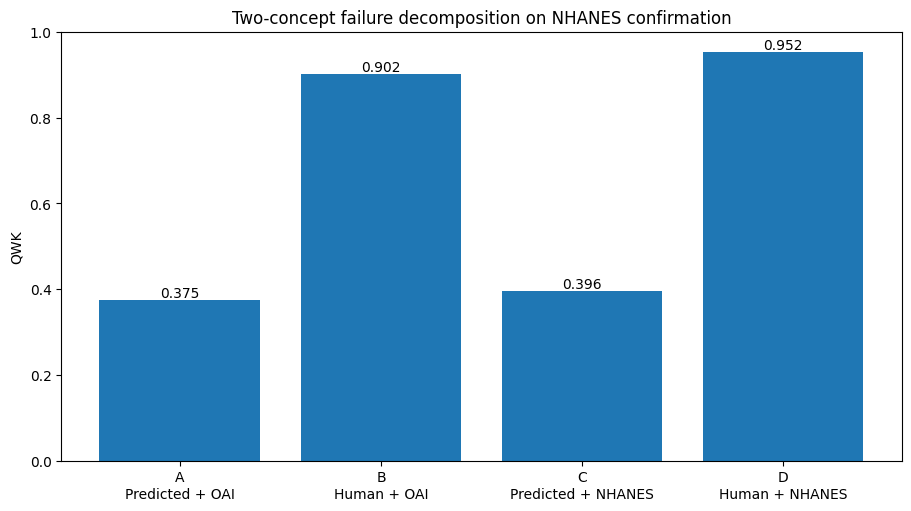

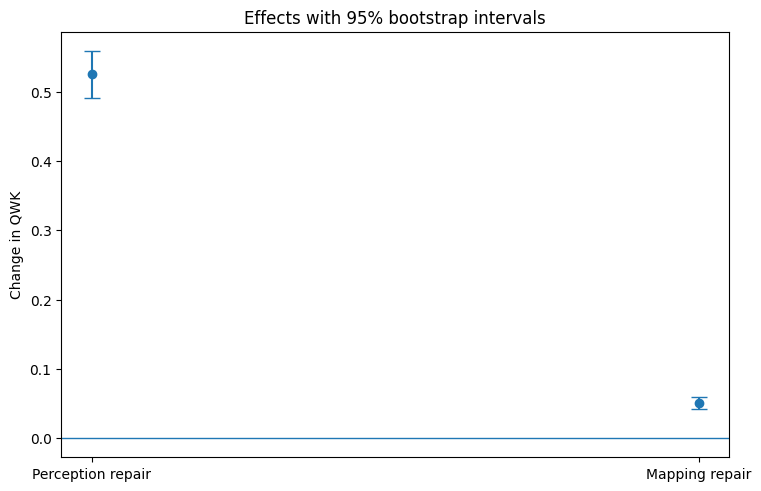

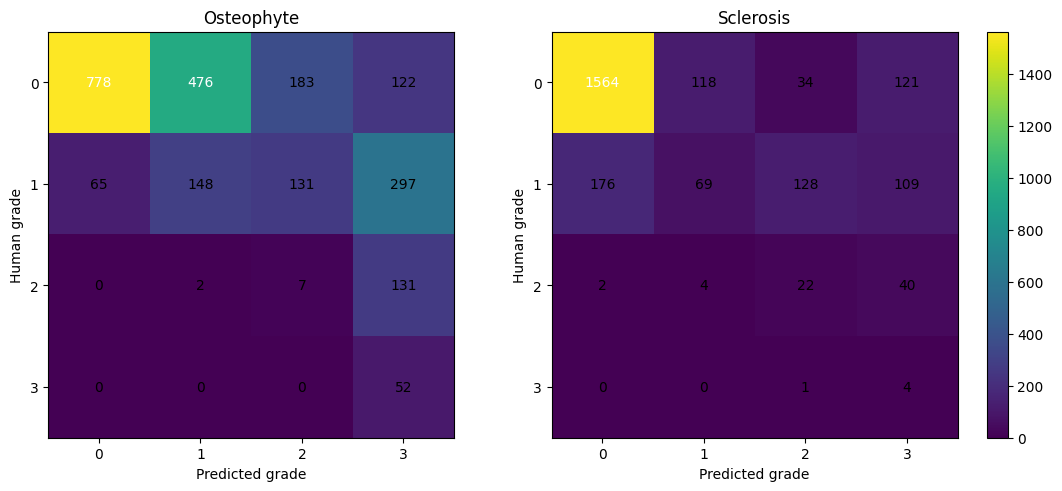

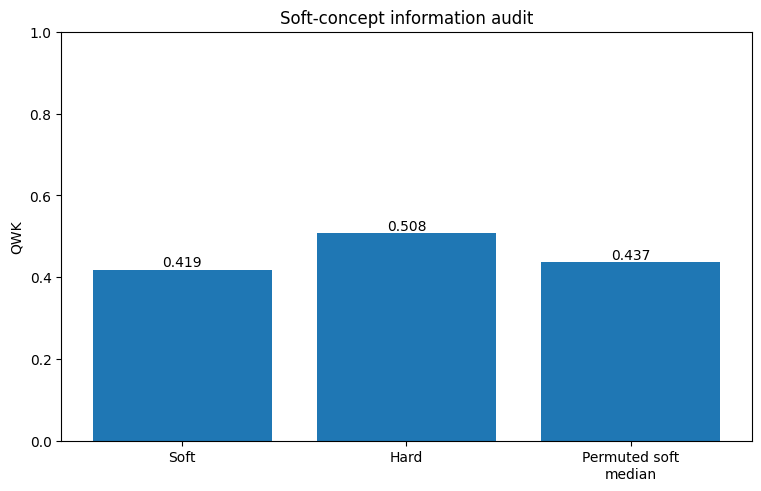

In [9]:



qwk_effects = effect_intervals.loc[effect_intervals['metric'].eq('qwk')].set_index('effect')

perception_estimate = float(qwk_effects.loc['perception_repair_source_mapping','estimate'])

perception_lower = float(qwk_effects.loc['perception_repair_source_mapping','ci_lower'])

mapping_estimate = float(qwk_effects.loc['mapping_repair_human_concepts','estimate'])

mapping_lower = float(qwk_effects.loc['mapping_repair_human_concepts','ci_lower'])



if perception_lower > 0 and perception_estimate > mapping_estimate + CONFIG.practical_margin:

    diagnosis = 'perception_dominates'

elif mapping_lower > 0 and mapping_estimate > perception_estimate + CONFIG.practical_margin:

    diagnosis = 'mapping_dominates'

elif perception_lower > 0 and mapping_lower > 0:

    diagnosis = 'both_contribute'

else:

    diagnosis = 'inconclusive'



grade_two = concept_grade_metrics.loc[

    concept_grade_metrics['concept'].eq('osteophyte_max') & concept_grade_metrics['grade'].eq(2)

]

grade_two_recall = (

    float(

        grade_two.iloc[0][

            "recall"

        ]

    )

    if len(grade_two) == 1

    else None

)



perception_upper = float(

    qwk_effects.loc[

        "perception_repair_source_mapping",

        "ci_upper",

    ]

)



mapping_upper = float(

    qwk_effects.loc[

        "mapping_repair_human_concepts",

        "ci_upper",

    ]

)



perception_to_mapping_ratio = (

    perception_estimate

    / mapping_estimate

    if mapping_estimate != 0

    else np.inf

)



verdict = {

    "diagnosis":

        diagnosis,



    "decomposition_scope":

        (

            "two shared concepts: "

            "osteophyte and sclerosis"

        ),



    "original_model_scope":

        (

            "three concepts: osteophyte, "

            "sclerosis and JSN"

        ),



    "selected_smoothing_alpha":

        float(

            SELECTED_ALPHA

        ),



    "perception_repair_qwk":

        float(

            perception_estimate

        ),



    "perception_repair_qwk_ci_lower":

        float(

            perception_lower

        ),



    "perception_repair_qwk_ci_upper":

        float(

            perception_upper

        ),



    "mapping_repair_qwk":

        float(

            mapping_estimate

        ),



    "mapping_repair_qwk_ci_lower":

        float(

            mapping_lower

        ),



    "mapping_repair_qwk_ci_upper":

        float(

            mapping_upper

        ),



    "perception_to_mapping_ratio":

        float(

            perception_to_mapping_ratio

        ),



    "osteophyte_grade_2_recall":

        grade_two_recall,



    "soft_information_verdict":

        leakage_verdict,



    "soft_minus_hard_qwk":

        float(

            soft_minus_hard_qwk

        ),



    "soft_minus_permuted_qwk":

        float(

            soft_minus_permuted_qwk

        ),



    "mapping_reconstruction_parity_max_difference":

        float(

            parity_max_difference

        ),

}



atomic_json(

    verdict,

    RESULT_DIR

    / "scientific_verdict.json",

)



diagnosis_table = pd.DataFrame([

    {

        **verdict,



        "difference_perception_minus_mapping":

            float(

                perception_estimate

                - mapping_estimate

            ),



        "claim":

            (

                "For OAI-to-NHANES transfer and "

                "the two shared concepts, concept "

                "perception failure is the dominant "

                "source of error."

                if diagnosis

                == "perception_dominates"

                else

                "The decomposition did not show a "

                "clear dominant failure source."

            ),

    }

])



atomic_csv(

    diagnosis_table,

    TABLE_DIR

    / "T09_diagnosis_summary.csv",

)



display(

    diagnosis_table.round(4)

)




order = ['A_predicted_OAI_mapping','B_human_OAI_mapping','C_predicted_NHANES_mapping','D_human_NHANES_mapping']

plot_data = condition_metrics.set_index('condition').loc[order]

figure, axis = plt.subplots(figsize=(9,5), constrained_layout=True)

bars = axis.bar(['A\nPredicted + OAI','B\nHuman + OAI','C\nPredicted + NHANES','D\nHuman + NHANES'], plot_data['qwk'])

axis.set_ylim(0,1); axis.set_ylabel('QWK'); axis.set_title('Two-concept failure decomposition on NHANES confirmation')

for bar in bars:

    axis.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{bar.get_height():.3f}',ha='center',va='bottom')

save_figure(figure,'F01_decomposition_conditions')




plot_effects = qwk_effects.loc[['perception_repair_source_mapping','mapping_repair_human_concepts']]

est = plot_effects['estimate'].to_numpy(dtype=float)

low = est - plot_effects['ci_lower'].to_numpy(dtype=float)

high = plot_effects['ci_upper'].to_numpy(dtype=float) - est

figure, axis = plt.subplots(figsize=(7.5,4.8), constrained_layout=True)

axis.errorbar(['Perception repair','Mapping repair'],est,yerr=np.vstack([low,high]),fmt='o',capsize=6)

axis.axhline(0,linewidth=1); axis.set_ylabel('Change in QWK'); axis.set_title('Effects with 95% bootstrap intervals')

save_figure(figure,'F02_effect_intervals')




figure, axes = plt.subplots(1,2,figsize=(11,4.8),constrained_layout=True)

for axis, concept in zip(axes,CONCEPT_COLUMNS):

    matrix = concept_confusions[concept]; image = axis.imshow(matrix)

    axis.set_xticks(range(4)); axis.set_yticks(range(4)); axis.set_xlabel('Predicted grade'); axis.set_ylabel('Human grade')

    axis.set_title(concept.replace('_max','').capitalize()); threshold = matrix.max()/2

    for row in range(4):

        for column in range(4):

            axis.text(column,row,str(matrix[row,column]),ha='center',va='center',color='white' if matrix[row,column]>threshold else 'black')

figure.colorbar(image,ax=axes,fraction=0.03,pad=0.03)

save_figure(figure,'F03_concept_confusions')




values = leakage_summary.set_index('condition').loc[['soft','hard','permuted_median'],'qwk'].to_numpy(dtype=float)

figure, axis = plt.subplots(figsize=(7.5,4.8), constrained_layout=True)

bars = axis.bar(['Soft','Hard','Permuted soft\nmedian'],values)

axis.set_ylim(0,1); axis.set_ylabel('QWK'); axis.set_title('Soft-concept information audit')

for bar in bars:

    axis.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{bar.get_height():.3f}',ha='center',va='bottom')

save_figure(figure,'F04_soft_information_audit')


## 8. Final audit

N03 passes when all analyses execute and fresh artifacts are saved. The scientific result may be positive, negative, mixed, or inconclusive.

In [10]:



required_files = [

    TABLE_DIR / 'T01_smoothing_selection.csv', TABLE_DIR / 'T02_mapping_tables.csv',

    TABLE_DIR / 'T03_condition_metrics.csv', TABLE_DIR / 'T04_bootstrap_draws.csv',

    TABLE_DIR / 'T05_effect_intervals.csv', TABLE_DIR / 'T06_concept_grade_metrics.csv',

    TABLE_DIR / 'T07_soft_information_summary.csv', TABLE_DIR / 'T08_soft_information_permutations.csv',

    TABLE_DIR / 'T09_diagnosis_summary.csv', PREDICTION_DIR / 'decomposition_predictions.csv',

    RESULT_DIR / 'scientific_verdict.json', RESULT_DIR / 'soft_information_verdict.json',

    FIGURE_DIR / 'F01_decomposition_conditions.png', FIGURE_DIR / 'F01_decomposition_conditions.pdf',

    FIGURE_DIR / 'F02_effect_intervals.png', FIGURE_DIR / 'F02_effect_intervals.pdf',

    FIGURE_DIR / 'F03_concept_confusions.png', FIGURE_DIR / 'F03_concept_confusions.pdf',

    FIGURE_DIR / 'F04_soft_information_audit.png', FIGURE_DIR / 'F04_soft_information_audit.pdf',

    MANIFEST_DIR / 'input_manifest.csv',

]



audit_rows = []

for path in required_files:

    exists = path.exists(); nonempty = exists and path.stat().st_size > 0

    fresh = nonempty and path.stat().st_mtime >= RUN_STARTED_TIMESTAMP - 1.0

    audit_rows.append({

        'file': path.name, 'path': str(path), 'exists': exists, 'nonempty': nonempty,

        'fresh': fresh, 'size_bytes': int(path.stat().st_size) if exists else None,

        'sha256': sha256_file(path) if nonempty else None,

    })

drive_audit = pd.DataFrame(audit_rows)

criteria = {

    'N02B passed': bool(N02B_STATUS.get('passed',False)),

    'source mapping uses OAI train and validation only': len(OAI_MAPPING_FRAME)>0,

    'target mapping uses NHANES Discovery only': len(NHANES_ADAPTATION)>0,

    'all four conditions were evaluated': len(condition_metrics)==4,

    'participant bootstrap completed': len(bootstrap_draws)==CONFIG.bootstrap_repetitions,

    'at least 99 percent of QWK draws are valid': bool((effect_intervals.loc[effect_intervals['metric'].eq('qwk'),'valid_draws'] >= int(.99*CONFIG.bootstrap_repetitions)).all()),

    'concept-grade analysis covers eight rows': len(concept_grade_metrics)==8,

    'mapping reconstruction parity passed': parity_max_difference<=5e-4,

    'soft-information permutations completed': len(permutation_results)==CONFIG.leakage_permutations,

    'scientific verdict produced': diagnosis in {'perception_dominates','mapping_dominates','both_contribute','inconclusive'},

    'two-concept diagnostic scope recorded': verdict[

        'decomposition_scope'

    ].startswith(

        'two shared concepts'

    ),

    'soft-information verdict uses three-way logic': leakage_verdict in {

        'soft_information_benefit',

        'soft_information_harm',

        'no_material_soft_information_effect',

    },

    'effect confidence intervals recorded': bool(

        np.isfinite([

            perception_lower,

            perception_upper,

            mapping_lower,

            mapping_upper,

        ]).all()

    ),

    'all required artifacts exist': bool(drive_audit['nonempty'].all()),

    'all required artifacts are fresh': bool(drive_audit['fresh'].all()),

    'all output paths use Final Pipeline': bool(drive_audit['path'].str.startswith(str(FINAL_ROOT)).all()),

}

criteria_table = pd.DataFrame([{'criterion':name,'passed':bool(value)} for name,value in criteria.items()])

passed = bool(criteria_table['passed'].all())

atomic_csv(drive_audit, RESULT_DIR / 'drive_save_audit.csv')

atomic_csv(criteria_table, RESULT_DIR / 'acceptance_criteria.csv')

status = {

    'stage':'N03','protocol':PROTOCOL,'passed':passed,'diagnosis':diagnosis,

    'selected_smoothing_alpha':SELECTED_ALPHA,'perception_repair_qwk':perception_estimate,

    'mapping_repair_qwk':mapping_estimate,'soft_information_verdict':leakage_verdict,

    'confirmation_knees':int(len(NHANES_CONFIRMATION)),

    'created_utc':datetime.now(timezone.utc).isoformat(),

}

atomic_json(status, RESULT_DIR / 'status.json')

manifest = pd.DataFrame([{

    'path':str(path.relative_to(FINAL_ROOT)),'size_bytes':int(path.stat().st_size),

    'sha256':sha256_file(path),'generator':NOTEBOOK_NAME,'protocol':PROTOCOL,

} for path in required_files if path.exists() and path.stat().st_size>0])

atomic_csv(manifest, MANIFEST_DIR / 'output_manifest.csv')

certificate_lines = ['='*78,'N03 FAILURE DECOMPOSITION CERTIFICATE','='*78]

for row in criteria_table.itertuples(index=False):

    certificate_lines.append(('PASS  ' if row.passed else 'FAIL  ')+str(row.criterion))

certificate_lines.extend([

    '',f'Diagnosis: {diagnosis}',f'Perception repair QWK: {perception_estimate:.4f}',

    f'Mapping repair QWK: {mapping_estimate:.4f}',f'Soft-information verdict: {leakage_verdict}',

    'FINAL STATUS: PASS' if passed else 'FINAL STATUS: FAIL',

    'READY FOR N04: YES' if passed else 'READY FOR N04: NO','='*78,

])

certificate='\n'.join(certificate_lines)

(RESULT_DIR/'certificate.txt').write_text(certificate,encoding='utf-8')

display(condition_metrics.round(4)); display(qwk_effects.reset_index().round(4)); display(criteria_table)

print('\n'+certificate)

if not passed:

    raise RuntimeError('N03 final audit failed.')


,condition,qwk,accuracy,balanced_accuracy,macro_f1,mae,within_one_accuracy,severe_error_rate
0,A_predicted_OAI_mapping,0.3751,0.3809,0.4282,0.3027,1.0652,0.5811,0.4189
1,B_human_OAI_mapping,0.9015,0.8056,0.4503,0.4444,0.2044,0.9900,0.0100
2,C_predicted_NHANES_mapping,0.3957,0.3131,0.3472,0.2027,1.2847,0.5489,0.4511
3,D_human_NHANES_mapping,0.9520,0.8783,0.7783,0.7588,0.1217,1.0000,0.0000


,effect,metric,estimate,ci_lower,ci_upper,valid_draws
0,perception_repair_source_mapping,qwk,0.5264,0.4918,0.5591,2000
1,mapping_repair_predicted_concepts,qwk,0.0206,0.0038,0.0376,2000
2,mapping_repair_human_concepts,qwk,0.0505,0.0423,0.0593,2000
3,perception_repair_target_mapping,qwk,0.5563,0.5292,0.5832,2000
4,interaction,qwk,0.0298,0.0099,0.0488,2000


,criterion,passed
0,N02B passed,True
1,source mapping uses OAI train and validation only,True
2,target mapping uses NHANES Discovery only,True
3,all four conditions were evaluated,True
4,participant bootstrap completed,True
5,at least 99 percent of QWK draws are valid,True
6,concept-grade analysis covers eight rows,True
7,mapping reconstruction parity passed,True
8,soft-information permutations completed,True
9,scientific verdict produced,True



N03 FAILURE DECOMPOSITION CERTIFICATE
PASS  N02B passed
PASS  source mapping uses OAI train and validation only
PASS  target mapping uses NHANES Discovery only
PASS  all four conditions were evaluated
PASS  participant bootstrap completed
PASS  at least 99 percent of QWK draws are valid
PASS  concept-grade analysis covers eight rows
PASS  mapping reconstruction parity passed
PASS  soft-information permutations completed
PASS  scientific verdict produced
PASS  two-concept diagnostic scope recorded
PASS  soft-information verdict uses three-way logic
PASS  effect confidence intervals recorded
PASS  all required artifacts exist
PASS  all required artifacts are fresh
PASS  all output paths use Final Pipeline

Diagnosis: perception_dominates
Perception repair QWK: 0.5264
Mapping repair QWK: 0.0505
Soft-information verdict: soft_information_harm
FINAL STATUS: PASS
READY FOR N04: YES
